<a href="https://colab.research.google.com/github/keermani006/MACHINE-LEARNING/blob/main/LAB-6/ML_LAB_6_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Machine Learning Laboratory: Property Unsold Analysis

**Problem Statement:**

"Maggie is a real-estate agent and she is puzzled about why some of the properties her company manages have not been sold for more than six months. Help Maggie in providing insights why the properties are not getting sold."

This notebook aims to generate a synthetic dataset representing real-estate properties, create a target variable indicating whether a property remains unsold for more than six months, and then apply logistic regression to identify key factors contributing to delayed sales.

In [1]:
# ============================================
# 1. IMPORT REQUIRED LIBRARIES
# ============================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, roc_auc_score

In [2]:
# ============================================
# 2. GENERATE SYNTHETIC REAL-ESTATE DATASET
# ============================================
np.random.seed(42) # Set a random seed for reproducibility

n = 500

data = pd.DataFrame({
    'Area_sqft': np.random.randint(600, 3500, n),
    'Bedrooms': np.random.randint(1, 6, n),
    'Bathrooms': np.random.randint(1, 5, n),
    'Age_years': np.random.randint(1, 40, n),
    'Distance_City_km': np.random.uniform(1, 30, n),
    'Price_Lakhs': np.random.uniform(30, 300, n),
    'Parking_Spaces': np.random.randint(0, 4, n),
    'Nearby_Schools': np.random.randint(0, 10, n)
})

In [3]:
# ============================================
# 3. DISPLAY DATASET
# ============================================
display(data.head())

,Area_sqft,Bedrooms,Bathrooms,Age_years,Distance_City_km,Price_Lakhs,Parking_Spaces,Nearby_Schools
0,1460,1,1,17,21.496539,241.623782,3,1
1,1894,1,3,10,5.844215,179.641159,2,2
2,1730,5,3,12,5.860957,31.411996,2,8
3,1695,3,2,16,2.063471,235.467505,2,6
4,2238,3,2,24,22.355658,39.534066,2,8


In [4]:
# ============================================
# 4. UNDERSTAND DATASET SHAPE
# ============================================
print(f"Dataset shape: {data.shape}")

Dataset shape: (500, 8)


In [5]:
# ============================================
# 5. CHECK DATA TYPES
# ============================================
display(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Area_sqft         500 non-null    int64  
 1   Bedrooms          500 non-null    int64  
 2   Bathrooms         500 non-null    int64  
 3   Age_years         500 non-null    int64  
 4   Distance_City_km  500 non-null    float64
 5   Price_Lakhs       500 non-null    float64
 6   Parking_Spaces    500 non-null    int64  
 7   Nearby_Schools    500 non-null    int64  
dtypes: float64(2), int64(6)
memory usage: 31.4 KB


None

In [6]:
# ============================================
# 6. CHECK MISSING VALUES
# ============================================
display(data.isnull().sum())

,0
Area_sqft,0
Bedrooms,0
Bathrooms,0
Age_years,0
Distance_City_km,0
Price_Lakhs,0
Parking_Spaces,0
Nearby_Schools,0


In [7]:
# ============================================
# 7. GENERATE TARGET VARIABLE
# ============================================
# Normalize relevant features to a 0-1 scale
data['Price_norm'] = (data['Price_Lakhs'] - data['Price_Lakhs'].min()) / (data['Price_Lakhs'].max() - data['Price_Lakhs'].min())
data['Distance_norm'] = (data['Distance_City_km'] - data['Distance_City_km'].min()) / (data['Distance_City_km'].max() - data['Distance_City_km'].min())
data['Age_norm'] = (data['Age_years'] - data['Age_years'].min()) / (data['Age_years'].max() - data['Age_years'].min())
data['Schools_norm'] = (data['Nearby_Schools'] - data['Nearby_Schools'].min()) / (data['Nearby_Schools'].max() - data['Nearby_Schools'].min())
data['Parking_norm'] = (data['Parking_Spaces'] - data['Parking_Spaces'].min()) / (data['Parking_Spaces'].max() - data['Parking_Spaces'].min())

# Create a propensity score for being unsold
# Higher Price, Distance, Age -> higher probability of unsold (positive coefficients)
# Lower Schools, Parking -> higher probability of unsold (negative coefficients for normalized values, or positive for inverse)
propensity_score = (
    data['Price_norm'] * 0.4 +
    data['Distance_norm'] * 0.3 +
    data['Age_norm'] * 0.2 +
    (1 - data['Schools_norm']) * 0.15 +
    (1 - data['Parking_norm']) * 0.1
)

# Scale propensity score to a probability range (e.g., 0.1 to 0.7) and add noise
base_probability = 0.1 + 0.6 * (propensity_score - propensity_score.min()) / (propensity_score.max() - propensity_score.min())
noise = np.random.normal(0, 0.1, n) # Add Gaussian noise

final_probability = np.clip(base_probability + noise, 0, 1)

# Set a threshold to convert probabilities to binary target
threshold = 0.5 # Adjust this to get a reasonable distribution
data['Unsold_6_Months'] = (final_probability > threshold).astype(int)

# Drop temporary normalized columns
data = data.drop(columns=['Price_norm', 'Distance_norm', 'Age_norm', 'Schools_norm', 'Parking_norm'])

Target Variable Distribution:


,count
Unsold_6_Months,
0,338
1,162


/tmp/ipykernel_1234/2621197131.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Unsold_6_Months', data=data, palette='viridis')


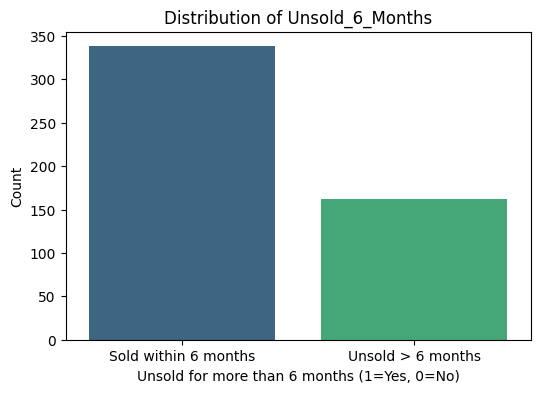

In [8]:
# ============================================
# 8. ANALYZE TARGET DISTRIBUTION
# ============================================
print("Target Variable Distribution:")
display(data['Unsold_6_Months'].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(x='Unsold_6_Months', data=data, palette='viridis')
plt.title('Distribution of Unsold_6_Months')
plt.xlabel('Unsold for more than 6 months (1=Yes, 0=No)')
plt.ylabel('Count')
plt.xticks([0, 1], ['Sold within 6 months', 'Unsold > 6 months'])
plt.show()

/tmp/ipykernel_1234/3065458841.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Nearby_Schools', data=data, palette='magma')
/tmp/ipykernel_1234/3065458841.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Parking_Spaces', data=data, palette='cividis')
/tmp/ipykernel_1234/3065458841.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Bedrooms', data=data, palette='viridis')
/tmp/ipykernel_1234/3065458841.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assi

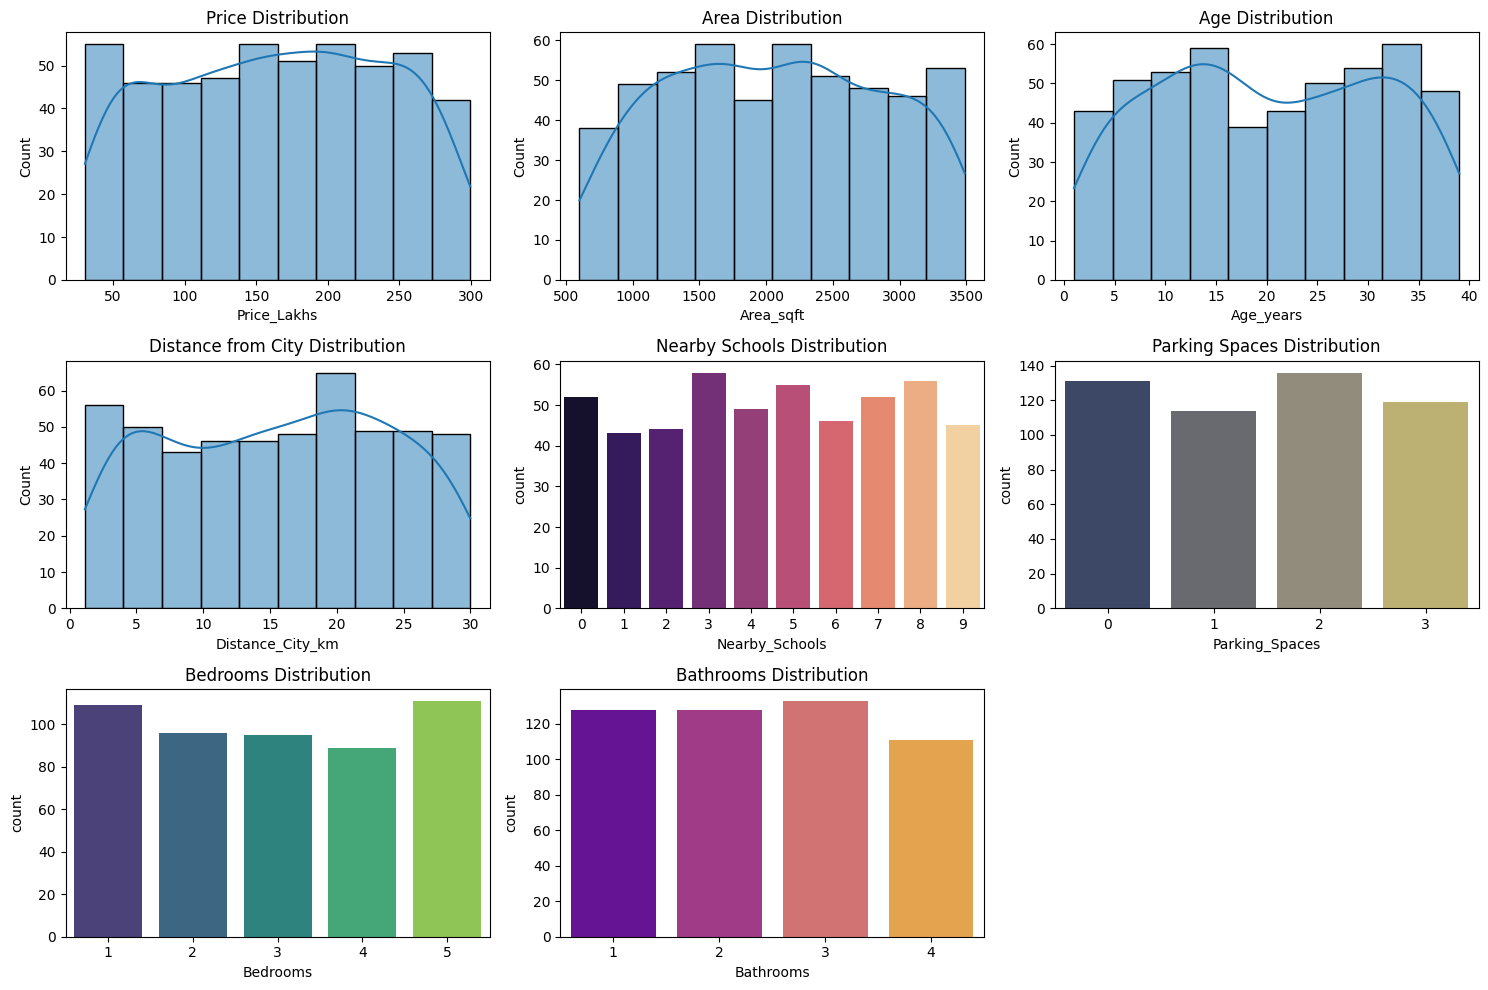

In [9]:
# ============================================
# 9. EXPLORATORY DATA ANALYSIS
# ============================================
plt.figure(figsize=(15, 10))

plt.subplot(3, 3, 1)
sns.histplot(data['Price_Lakhs'], kde=True)
plt.title('Price Distribution')

plt.subplot(3, 3, 2)
sns.histplot(data['Area_sqft'], kde=True)
plt.title('Area Distribution')

plt.subplot(3, 3, 3)
sns.histplot(data['Age_years'], kde=True)
plt.title('Age Distribution')

plt.subplot(3, 3, 4)
sns.histplot(data['Distance_City_km'], kde=True)
plt.title('Distance from City Distribution')

plt.subplot(3, 3, 5)
sns.countplot(x='Nearby_Schools', data=data, palette='magma')
plt.title('Nearby Schools Distribution')

plt.subplot(3, 3, 6)
sns.countplot(x='Parking_Spaces', data=data, palette='cividis')
plt.title('Parking Spaces Distribution')

plt.subplot(3, 3, 7)
sns.countplot(x='Bedrooms', data=data, palette='viridis')
plt.title('Bedrooms Distribution')

plt.subplot(3, 3, 8)
sns.countplot(x='Bathrooms', data=data, palette='plasma')
plt.title('Bathrooms Distribution')

plt.tight_layout()
plt.show()

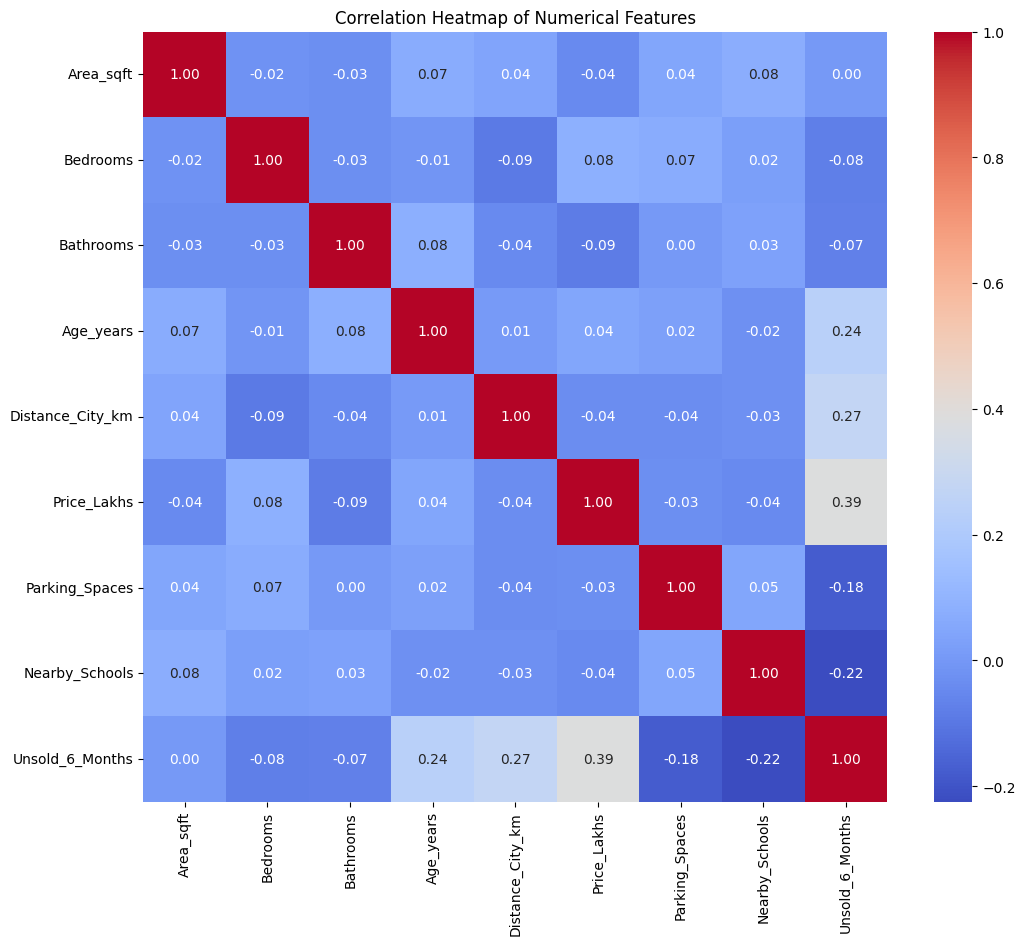

In [22]:
# ============================================
# 10. CORRELATION ANALYSIS
# ============================================
plt.figure(figsize=(12, 10))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

/tmp/ipykernel_1234/1474047624.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Unsold_6_Months', y=feature, data=data, ax=axes[i], palette='crest')
/tmp/ipykernel_1234/1474047624.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Sold', 'Unsold'])
/tmp/ipykernel_1234/1474047624.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Unsold_6_Months', y=feature, data=data, ax=axes[i], palette='crest')
/tmp/ipykernel_1234/1474047624.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i

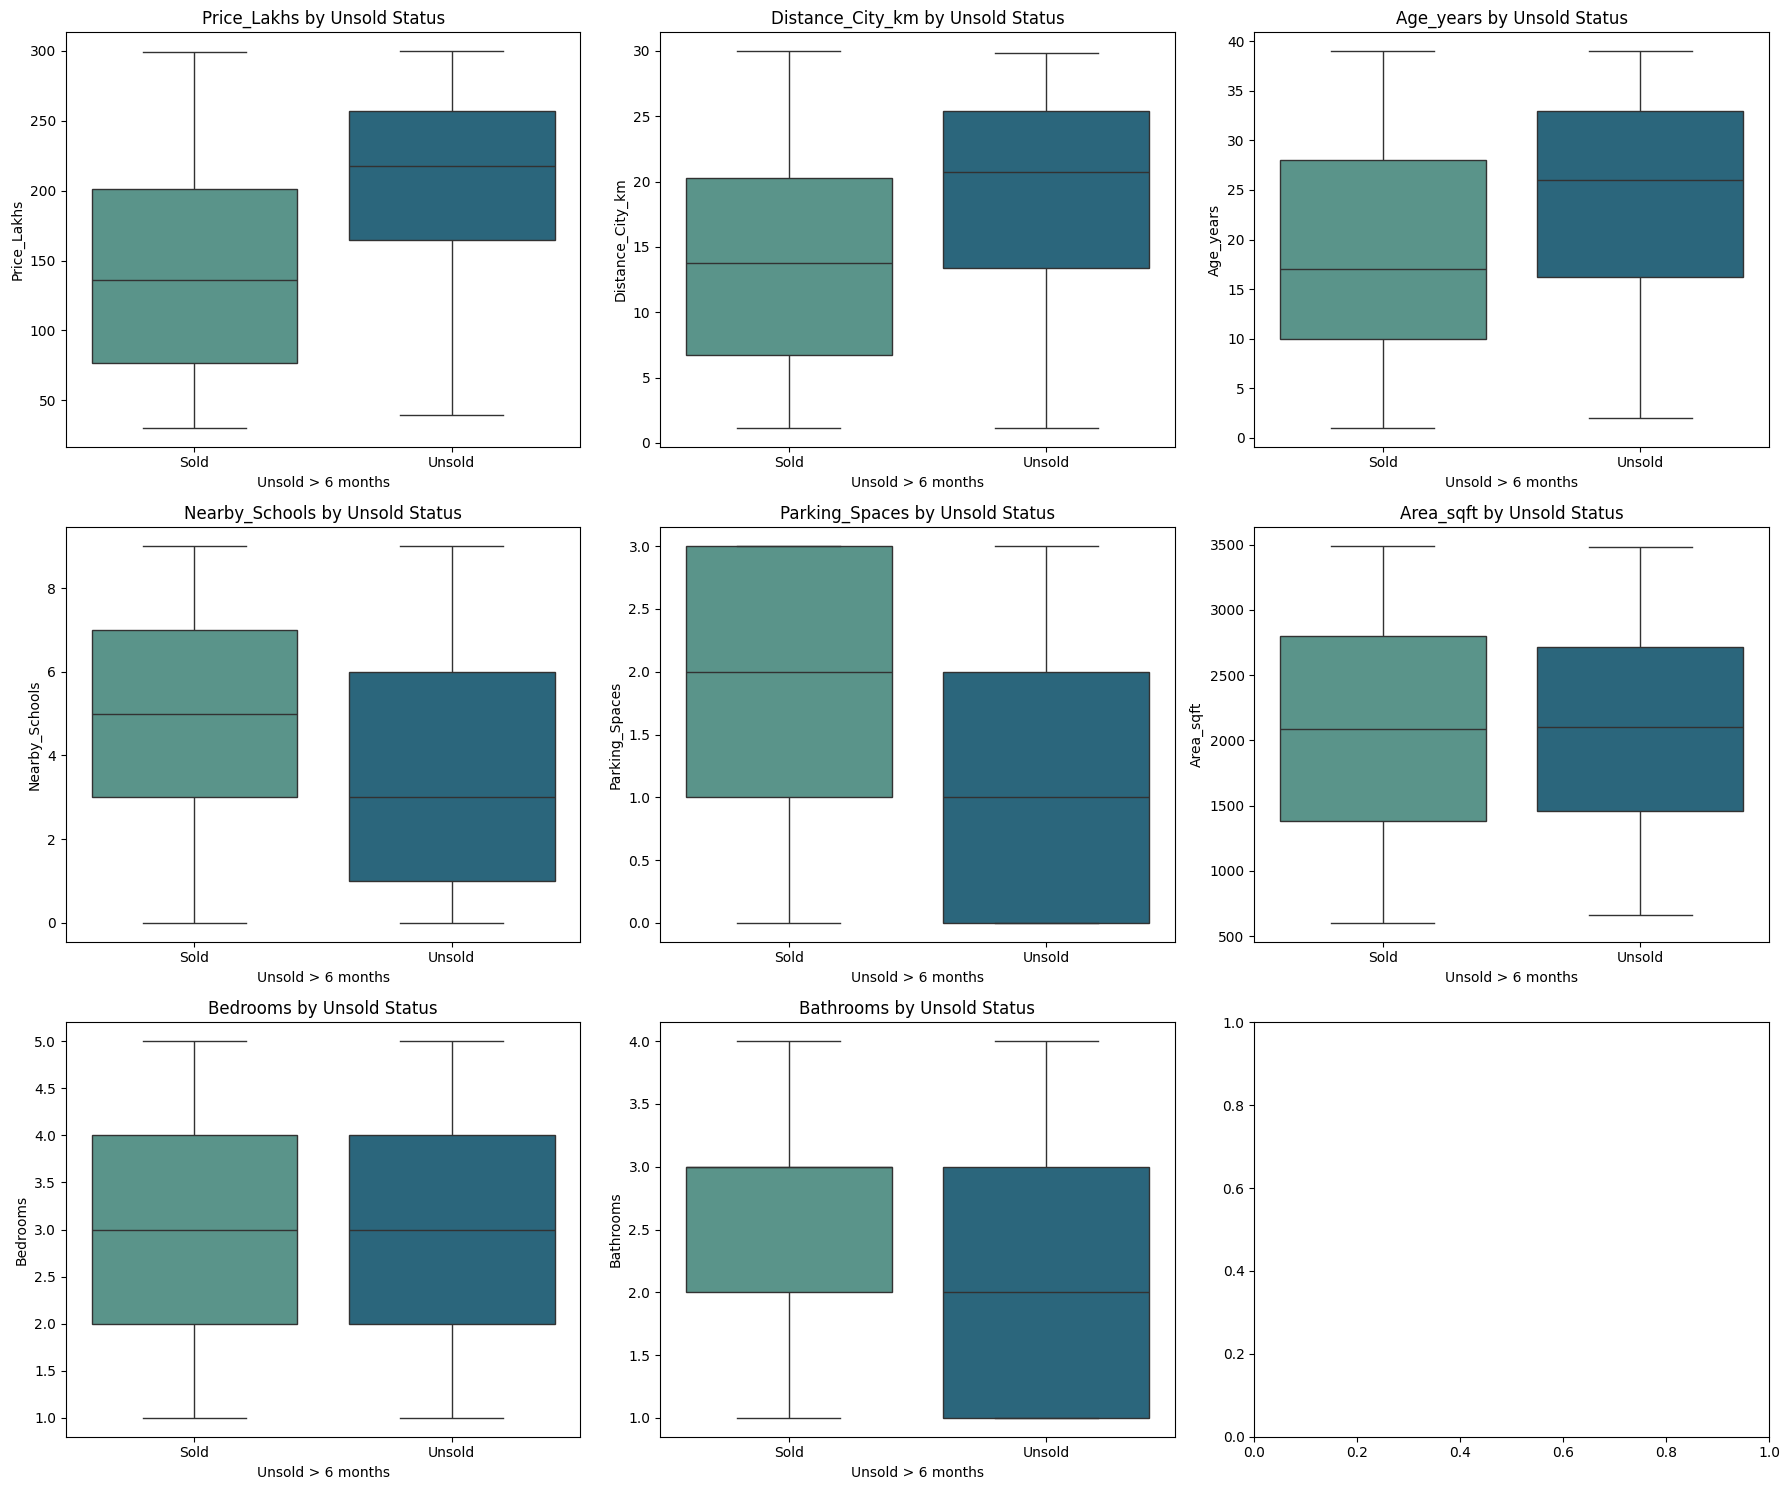

In [10]:
# ============================================
# 11. ANALYZE IMPORTANT FEATURES
# ============================================
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

features_to_compare = ['Price_Lakhs', 'Distance_City_km', 'Age_years', 'Nearby_Schools', 'Parking_Spaces', 'Area_sqft', 'Bedrooms', 'Bathrooms']

for i, feature in enumerate(features_to_compare):
    sns.boxplot(x='Unsold_6_Months', y=feature, data=data, ax=axes[i], palette='crest')
    axes[i].set_title(f'{feature} by Unsold Status')
    axes[i].set_xlabel('Unsold > 6 months')
    axes[i].set_ylabel(feature)
    axes[i].set_xticklabels(['Sold', 'Unsold'])

plt.tight_layout()
plt.show()

In [11]:
# ============================================
# 12. PREPARE FEATURES AND TARGET
# ============================================
X = data.drop('Unsold_6_Months', axis=1)
y = data['Unsold_6_Months']

In [12]:
# ============================================
# 13. TRAIN-TEST SPLIT
# ============================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [13]:
# ============================================
# 14. FEATURE SCALING
# ============================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
# ============================================
# 15. TRAIN LOGISTIC REGRESSION MODEL
# ============================================
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

In [15]:
# ============================================
# 16. MAKE PREDICTIONS
# ============================================
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

In [16]:
# ============================================
# 17. MODEL ACCURACY
# ============================================
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

Model Accuracy: 0.7900


Confusion Matrix:


array([[60,  8],
       [13, 19]])

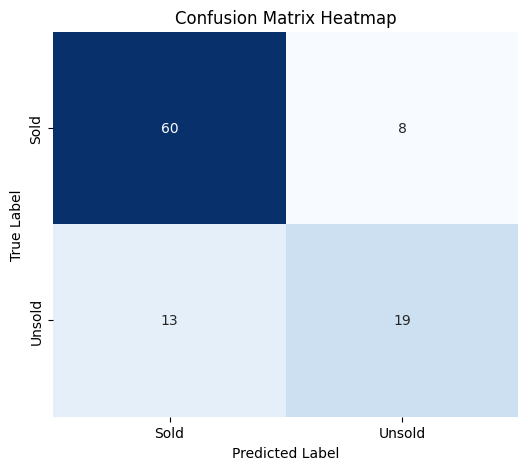

In [17]:
# ============================================
# 18. CONFUSION MATRIX
# ============================================
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
display(cm)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Sold', 'Unsold'], yticklabels=['Sold', 'Unsold'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap')
plt.show()

In [18]:
# ============================================
# 19. CLASSIFICATION REPORT
# ============================================
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.88      0.85        68
           1       0.70      0.59      0.64        32

    accuracy                           0.79       100
   macro avg       0.76      0.74      0.75       100
weighted avg       0.78      0.79      0.78       100



ROC AUC Score: 0.8695


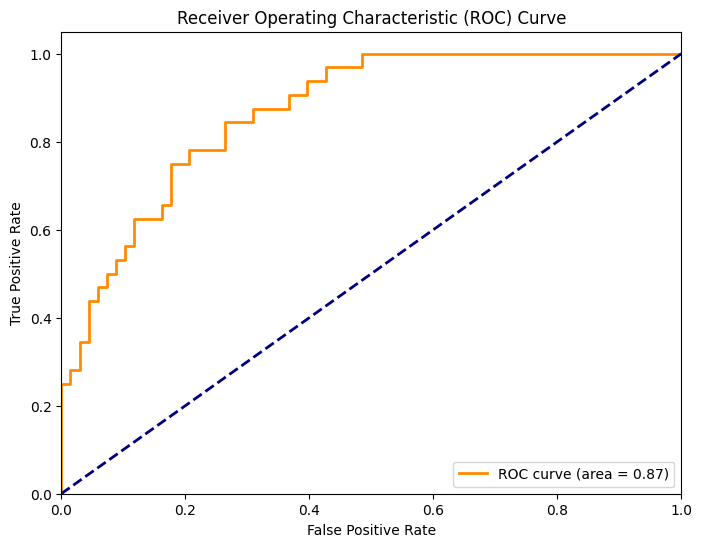

In [19]:
# ============================================
# 20. ROC CURVE AND AUC
# ============================================
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"ROC AUC Score: {roc_auc:.4f}")

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [20]:
# ============================================
# 21. ANALYZE LOGISTIC REGRESSION COEFFICIENTS
# ============================================
coefficients = model.coef_[0]
feature_names = X.columns

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

coef_df['Direction'] = coef_df['Coefficient'].apply(lambda x: 'Higher probability of being unsold' if x > 0 else 'Lower probability of being unsold')

coef_df = coef_df.sort_values(by='Coefficient', ascending=False)
display(coef_df)

,Feature,Coefficient,Direction
5,Price_Lakhs,1.106270,Higher probability of being unsold
4,Distance_City_km,0.844976,Higher probability of being unsold
3,Age_years,0.724848,Higher probability of being unsold
0,Area_sqft,0.076549,Higher probability of being unsold
2,Bathrooms,-0.117036,Lower probability of being unsold
1,Bedrooms,-0.305706,Lower probability of being unsold
6,Parking_Spaces,-0.576172,Lower probability of being unsold
7,Nearby_Schools,-0.585311,Lower probability of being unsold


In [21]:
# ============================================
# 22. IDENTIFY FACTORS ASSOCIATED WITH UNSOLD PROPERTIES
# ============================================
# This section is primarily for qualitative analysis based on the coef_df from the previous cell.
# No new code to generate, the insights will be discussed in the markdown cells.


### CONCLUSION

Logistic Regression proves to be a valuable tool for Maggie. By analyzing the coefficients of the trained model, she can identify properties that are more likely to remain unsold due to specific characteristics. For instance, if a property has a high price, is far from the city, is older, lacks good schools nearby, or offers insufficient parking, the model provides a quantifiable indication that it faces a higher risk of delayed sale. This allows Maggie to proactively adjust her sales strategies, such as recommending price reductions, highlighting alternative benefits for distant or older properties, or suggesting improvements (if feasible) to address issues like parking or school access. Ultimately, Logistic Regression provides a data-driven framework for Maggie to understand the underlying reasons for delayed sales and make informed decisions to improve her company's property turnover.